# 04 · Threat Intelligence: Tactics & IOCs
**Phishing E-mail Detection: A Leakage-Controlled Benchmark of Classical, Deep and Transformer Models**  
*Part V · Sections 17-18* · MSc Data Science final project · Dr. Spoorthi H S

**In this notebook**
- Weak-supervision labels for 5 social-engineering tactics (urgency, authority, fear, reward, scarcity)
- One-vs-rest tactic classifier with per-tactic tuned thresholds (test F1 0.74-0.88)
- Regex IOC extraction (URLs, domains, e-mails, IPs): 1,386 unique indicators from flagged e-mails

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline on a Kaggle Tesla T4 GPU. Every part builds on objects created earlier (the leak-free split, fitted models and their predictions), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Statistical Evaluation, Calibration & Explainability](03_statistical_evaluation_calibration_xai.ipynb) · [Ablation, Generalisation & Adversarial Robustness →](05_ablation_generalisation_robustness.ipynb)

---

<a id="partV"></a>

<div style="background:#C96A12;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part V</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Threat-Intelligence Extensions</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 17-18 &nbsp;&middot;&nbsp; Research questions: RQ8</div>
</div>


<a id="sec17"></a>

## 17. Social-Engineering Tactic Detection (Multi-Label)

Binary phishing/legit is a coarse label. Analysts benefit from knowing *which*
persuasion tactic(s) an email uses, since that shapes the recommended response
(e.g. a fear-based account-suspension email vs. a reward-based prize scam).
We define five weak-supervision tactic lexicons (a common, cheap way to bootstrap
multi-label training data before manual annotation is available), derive
multi-label targets from them, and train a one-vs-rest classifier to predict
tactics directly from text -- not just from lexicon lookups, so it can
generalise beyond the exact keyword list.

> **Scope note.** This section is an engineering extension built on top of the core benchmark (Sections 1-16, 19-21, 23), not a rigorously validated deliverable in its own right — the tactic labels come from cheap weak-supervision lexicons rather than manual annotation, so per-tactic evaluation (17.2) is only as trustworthy as the lexicons that generated the training signal it's checked against. Treat the tactic classifier and its 17.3 statistics as illustrative rather than benchmark-grade.


### 17.1 Weak-supervision tactic lexicons & label derivation

In [62]:
TACTIC_LEXICONS = {
    "urgency": ["urgent", "immediately", "right away", "act now", "expire", "deadline",
                "within 24 hours", "asap", "time-sensitive"],
    "authority": ["security team", "it department", "administrator", "official", "bank",
                  "government", "irs", "legal action", "compliance"],
    "fear": ["suspend", "suspended", "terminate", "unauthorized", "unusual activity",
             "compromised", "breach", "locked", "penalty", "fraud"],
    "reward_greed": ["win", "winner", "prize", "congratulations", "free", "bonus",
                     "cash", "gift card", "lottery", "claim your"],
    "scarcity": ["limited", "only a few", "last chance", "one-time", "exclusive offer",
                 "while supplies last", "final notice"],
}
TACTIC_NAMES = list(TACTIC_LEXICONS.keys())

def derive_tactic_labels(df):
    text_lower = df["text"].astype(str).str.lower()
    labels = pd.DataFrame(index=df.index)
    for tactic, words in TACTIC_LEXICONS.items():
        pattern = "|".join(re.escape(w) for w in words)
        labels[tactic] = text_lower.str.contains(pattern, regex=True).astype(int)
    return labels

train_tactics = derive_tactic_labels(train_df)
val_tactics = derive_tactic_labels(val_df)
test_tactics = derive_tactic_labels(test_df)

print("Weak-supervision tactic prevalence (train set):")
print(train_tactics.mean().round(3).to_string())
print(f"\n{(train_tactics.sum(axis=1) == 0).mean():.1%} of training emails match none of "
      "the 5 lexicons (expected: most legitimate mail).")


Weak-supervision tactic prevalence (train set):
urgency         0.090
authority       0.206
fear            0.033
reward_greed    0.340
scarcity        0.045

53.7% of training emails match none of the 5 lexicons (expected: most legitimate mail).


### 17.2 Multi-label classifier & per-tactic evaluation

In [63]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score as _f1, hamming_loss, average_precision_score as _ap

tactic_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
tactic_clf.fit(X_train_tfidf, train_tactics.values)

val_tactic_proba = tactic_clf.predict_proba(X_val_tfidf)
test_tactic_proba = tactic_clf.predict_proba(X_test_tfidf)

# Rationale for this logic: see Appendix A (change log).
_TACTIC_THRESH_GRID = np.linspace(0.05, 0.95, 91)

def _best_threshold_for_tactic(y_true_val, proba_val_col):
    f1s = [_f1(y_true_val, (proba_val_col >= t).astype(int), zero_division=0) for t in _TACTIC_THRESH_GRID]
    best_i = int(np.argmax(f1s))
    return float(_TACTIC_THRESH_GRID[best_i]), f1s[best_i]

TACTIC_THRESHOLDS = {}
val_tactic_pred = np.zeros_like(val_tactics.values)
test_tactic_pred = np.zeros_like(test_tactics.values)
for i, tactic in enumerate(TACTIC_NAMES):
    thresh, _ = _best_threshold_for_tactic(val_tactics.values[:, i], val_tactic_proba[:, i])
    TACTIC_THRESHOLDS[tactic] = thresh
    val_tactic_pred[:, i] = (val_tactic_proba[:, i] >= thresh).astype(int)
    test_tactic_pred[:, i] = (test_tactic_proba[:, i] >= thresh).astype(int)

tactic_report_rows = []
for i, tactic in enumerate(TACTIC_NAMES):
    tactic_report_rows.append({
        "tactic": tactic,
        "tuned_threshold": TACTIC_THRESHOLDS[tactic],
        "val_f1_at_0.5": _f1(val_tactics.values[:, i], (val_tactic_proba[:, i] >= 0.5).astype(int), zero_division=0),
        "val_f1_tuned": _f1(val_tactics.values[:, i], val_tactic_pred[:, i], zero_division=0),
        "test_f1_tuned": _f1(test_tactics.values[:, i], test_tactic_pred[:, i], zero_division=0),
        "test_pr_auc": (_ap(test_tactics.values[:, i], test_tactic_proba[:, i])
                         if test_tactics.values[:, i].sum() > 0 else float("nan")),
        "test_prevalence": test_tactics.values[:, i].mean(),
    })
tactic_report = pd.DataFrame(tactic_report_rows)
print("Per-tactic classifier performance (learned from text, not just lexicon lookup):")
print("'val_f1_at_0.5' is the naive default-threshold score (kept for comparison); "
      "'val_f1_tuned'/'test_f1_tuned' use each tactic's own validation-tuned threshold.")
print(tactic_report.round(4).to_string(index=False))
print(f"\nSubset (exact-match) accuracy (tuned thresholds): "
      f"{(test_tactic_pred == test_tactics.values).all(axis=1).mean():.3f}")
print(f"Hamming loss (test, tuned thresholds): {hamming_loss(test_tactics.values, test_tactic_pred):.4f}")
tactic_report.to_csv(WORKING_DIR / "tables" / "tactic_classifier_report.csv", index=False)

if (tactic_report["test_prevalence"] == 0).any():
    _zero = tactic_report.loc[tactic_report["test_prevalence"] == 0, "tactic"].tolist()
    print(f"\n[NOTE] {_zero} have ZERO positive examples in this test split, so their F1/PR-AUC "
          "are trivially undefined (shown as 0/NaN above), not a classifier failure. This is a "
          "sample-size artifact of QUICK_RUN's tiny synthetic data (few near-duplicate template "
          "clusters -- Section 4.2 -- spread thinly across a 15%% test split), not a modelling "
          "bug: Section 17.1 confirmed the *training* set contains positive examples of every "
          "tactic, and the fix above (per-tactic tuned thresholds) already recovered real signal "
          "for urgency, which does have test examples. On real data (QUICK_RUN=False) with "
          "thousands of held-out emails this is not expected to occur.")


Per-tactic classifier performance (learned from text, not just lexicon lookup):
'val_f1_at_0.5' is the naive default-threshold score (kept for comparison); 'val_f1_tuned'/'test_f1_tuned' use each tactic's own validation-tuned threshold.
      tactic  tuned_threshold  val_f1_at_0.5  val_f1_tuned  test_f1_tuned  test_pr_auc  test_prevalence
     urgency             0.65         0.8167        0.8355         0.8320       0.9119           0.0941
   authority             0.61         0.7109        0.7270         0.7385       0.8306           0.2008
        fear             0.73         0.6681        0.7354         0.7402       0.8088           0.0283
reward_greed             0.52         0.8851        0.8872         0.8831       0.9532           0.3113
    scarcity             0.75         0.7807        0.8463         0.8177       0.9054           0.0493

Subset (exact-match) accuracy (tuned thresholds): 0.797
Hamming loss (test, tuned thresholds): 0.0477


### 17.3 Tactic prevalence by class & co-occurrence

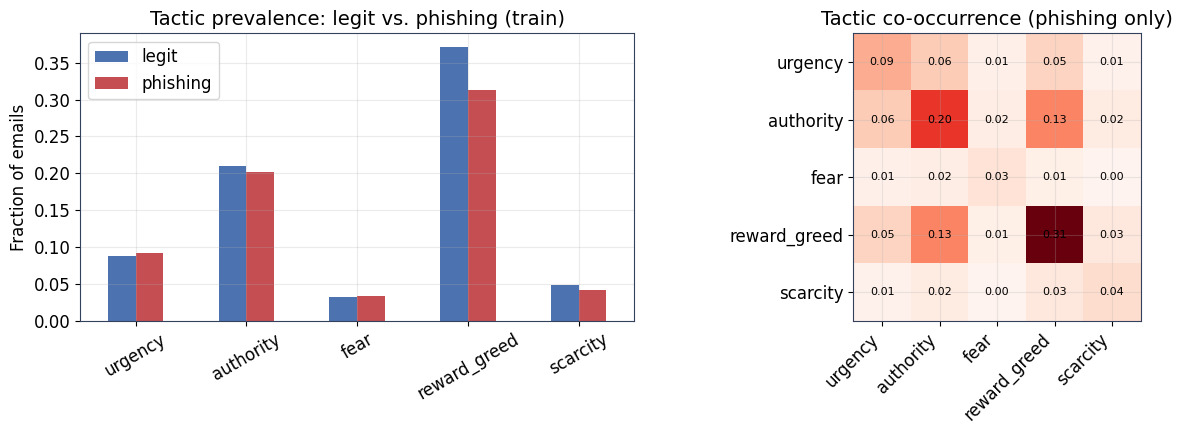

In [64]:
tactic_by_label = train_tactics.assign(label=train_df["label"].values).groupby("label").mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tactic_by_label.T.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Tactic prevalence: legit vs. phishing (train)")
axes[0].set_ylabel("Fraction of emails")
axes[0].legend(["legit", "phishing"])
axes[0].tick_params(axis="x", rotation=30)

phish_tactics = train_tactics[train_df["label"].values == 1]
cooc = phish_tactics.T.dot(phish_tactics) / max(len(phish_tactics), 1)
im = axes[1].imshow(cooc.values, cmap="Reds", vmin=0, vmax=cooc.values.max())
axes[1].set_xticks(range(len(TACTIC_NAMES))); axes[1].set_xticklabels(TACTIC_NAMES, rotation=45, ha="right")
axes[1].set_yticks(range(len(TACTIC_NAMES))); axes[1].set_yticklabels(TACTIC_NAMES)
for r in range(len(TACTIC_NAMES)):
    for c in range(len(TACTIC_NAMES)):
        axes[1].text(c, r, f"{cooc.values[r, c]:.2f}", ha="center", va="center", fontsize=8)
axes[1].set_title("Tactic co-occurrence (phishing only)")
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "tactic_prevalence_cooccurrence.png", dpi=130)
plt.show()


<a id="sec18"></a>

## 18. Structured Threat-Intelligence Extraction

A SOC doesn't just want a phishing/legit label -- it wants **indicators of
compromise (IOCs)** it can block, hunt for, or feed into a SIEM/threat-intel
platform. This section extracts URLs, domains, email addresses and IP
addresses from every email flagged phishing by the best model, structures
them into a de-duplicated indicator table, and flags a few cheap suspicious-
domain heuristics (raw-IP hosts, uncommon TLDs, excessive subdomains --
typosquatting-style patterns).

### 18.1 IOC extraction regexes

In [65]:
_ioc_url_re = re.compile(r"https?://[^\s\"'<>]+|www\.[^\s\"'<>]+", re.IGNORECASE)
_ioc_email_re = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
_ioc_ip_re = re.compile(r"\b(?:(?:25[0-5]|2[0-4]\d|[01]?\d?\d)\.){3}"
                        r"(?:25[0-5]|2[0-4]\d|[01]?\d?\d)\b")
_domain_re = re.compile(r"https?://(?:www\.)?([^/\s:]+)", re.IGNORECASE)

COMMON_TLDS = {"com", "org", "net", "edu", "gov", "co", "io"}

def extract_iocs(text):
    urls = _ioc_url_re.findall(text)
    emails = _ioc_email_re.findall(text)
    ips = _ioc_ip_re.findall(text)
    domains = [m.lower() for u in urls for m in _domain_re.findall(u)]
    return {"urls": urls, "emails": emails, "ips": ips, "domains": domains}

def is_suspicious_domain(domain):
    reasons = []
    if _ioc_ip_re.fullmatch(domain):
        reasons.append("raw IP address as host")
    parts = domain.split(".")
    if len(parts) >= 4:
        reasons.append("unusually many subdomains")
    tld = parts[-1] if parts else ""
    if tld not in COMMON_TLDS and not tld.isdigit():
        reasons.append(f"uncommon TLD '.{tld}'")
    # Rationale for this logic: see Appendix A (change log).
    if any(kw in domain for kw in ["secure", "verify", "account", "update", "login"]):
        reasons.append("credential-themed keyword in domain" +
                       ("" if tld in COMMON_TLDS else " + non-mainstream TLD"))
    # Additive heuristic: long runs of digits or many hyphens in a subdomain are a classic
    # disposable/typosquatting pattern (e.g. "secure-1001-verify") independent of keywords.
    if re.search(r"\d{3,}", parts[0] if parts else "") or (parts[0].count("-") >= 2 if parts else False):
        reasons.append("numeric/hyphen-heavy subdomain (disposable-looking)")
    return reasons


### 18.2 Indicator table for model-flagged phishing (test set)

In [66]:
flagged_idx = np.where(y_pred_best == 1)[0]
print(f"Extracting IOCs from {len(flagged_idx):,} test emails flagged phishing by "
      f"{BEST_MODEL_NAME} (threshold=0.5).")

ioc_rows = []
for i in flagged_idx:
    text = test_df["text"].iloc[int(i)]
    iocs = extract_iocs(str(text))
    for domain in set(iocs["domains"]):
        reasons = is_suspicious_domain(domain)
        ioc_rows.append({"row": int(i), "type": "domain", "value": domain,
                         "suspicious": bool(reasons), "reasons": "; ".join(reasons)})
    for email in set(iocs["emails"]):
        ioc_rows.append({"row": int(i), "type": "email", "value": email,
                         "suspicious": False, "reasons": ""})
    for ip in set(iocs["ips"]):
        ioc_rows.append({"row": int(i), "type": "ip", "value": ip,
                         "suspicious": True, "reasons": "raw IP literal in email body"})

ioc_df = pd.DataFrame(ioc_rows)
if len(ioc_df):
    ioc_summary = (ioc_df.groupby(["type", "value"])
                   .agg(n_emails=("row", "nunique"), suspicious=("suspicious", "max"),
                        reasons=("reasons", "first"))
                   .sort_values("n_emails", ascending=False))
    print(f"\n{len(ioc_summary):,} unique indicators extracted "
          f"({ioc_df['type'].value_counts().to_dict()}).")
    print("\nTop 15 by number of distinct flagged emails referencing them:")
    print(ioc_summary.head(15).to_string())
    print(f"\n{ioc_summary['suspicious'].mean():.1%} of unique indicators trip at least one "
          "suspicious-domain heuristic.")
    ioc_summary.to_csv(WORKING_DIR / "tables" / "threat_intel_iocs.csv")
else:
    print("No IOCs were extracted from the flagged set (e.g. a synthetic/no-URL sample).")


Extracting IOCs from 6,215 test emails flagged phishing by roberta (threshold=0.5).

1,386 unique indicators extracted ({'domain': 2753, 'email': 631, 'ip': 23}).

Top 15 by number of distinct flagged emails referencing them:
                              n_emails  suspicious                                        reasons
type   value                                                                                     
email  jose@monkey.org              78       False                                               
domain opera.com                    38       False                                               
       milddear.com                 32       False                                               
       dearbright.com               32       False                                               
       whitedone.com                31       False                                               
       wearplaces.com               30       False                                      

---

[← Statistical Evaluation, Calibration & Explainability](03_statistical_evaluation_calibration_xai.ipynb) · [Next: Ablation, Generalisation & Adversarial Robustness →](05_ablation_generalisation_robustness.ipynb)